<a href="https://colab.research.google.com/github/Evsstah/data_analysis/blob/master/num1(lab4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Информация о данных ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB

=== Количество пропущенных значений по каждому признаку ===
ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weigh

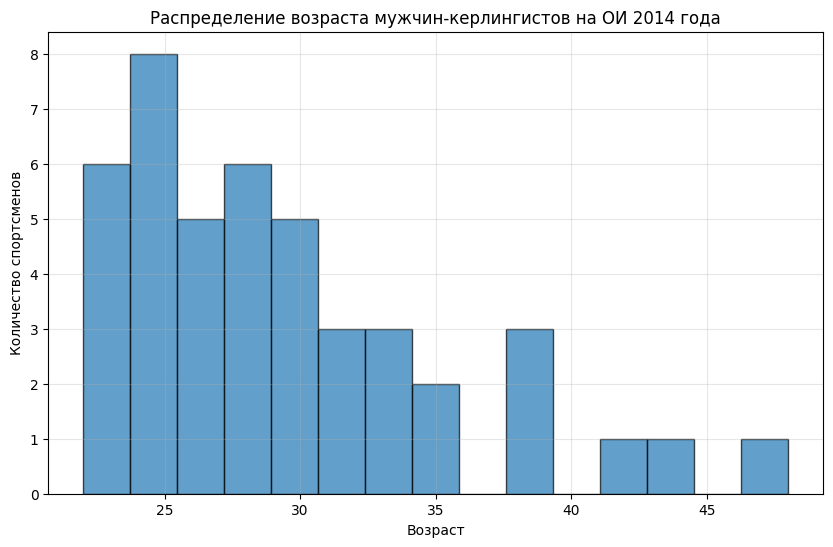


7) Статистика по странам на зимней ОИ 2006 года (только с медалями):
     Medal_Count    Avg_Age
NOC                        
CAN         69.0  25.481967
SWE         64.0  26.791667
GER         54.0  27.376426
USA         52.0  25.818462
RUS         41.0  25.784452
FIN         41.0  26.614286
AUT         30.0  27.704545
CZE         27.0  26.276471
ITA         25.0  26.727586
NOR         23.0  28.186335

8) Сводная таблица медалей по достоинству для зимней ОИ 2006 года:
Medal  Bronze  Gold  Silver
NOC                        
AUS         1     1       0
AUT         7    16       7
BLR         0     0       1
BUL         0     0       1
CAN        11    30      28
CHN         6     2       5
CRO         0     1       2
CZE        24     1       2
EST         0     3       0
FIN         7     0      34

ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ
Общее количество записей: 271116
Период данных: 1896 - 2016 годы
Количество уникальных спортсменов: 135571
Количество уникальных стран: 230


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Загрузка данных
df = pd.read_csv('athlete_events.csv')

# 2. Определение количества значений каждого признака и пропущенных данных
print("=== Информация о данных ===")
df.info()

print("\n=== Количество пропущенных значений по каждому признаку ===")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nПризнак с наибольшим количеством пропущенных данных: {missing_values.idxmax()} ({missing_values.max()} пропусков)")

# 3. Статистическая информация по полям: возраст, рост, вес
print("\n=== Статистическая информация по числовым признакам ===")
stats = df[['Age', 'Height', 'Weight']].describe()
print(stats)

# 4. Ответы на вопросы
print("\n" + "="*50)
print("ОТВЕТЫ НА ВОПРОСЫ")
print("="*50)

# 1) Самый молодой участник ОИ 1992 года
youngest_1992 = df[df['Year'] == 1992].nsmallest(1, 'Age')[['Name', 'Age', 'Event', 'Sport']]
print("\n1) Самый молодой участник ОИ 1992 года:")
print(youngest_1992)

# 2) Список всех видов спорта
all_sports = df['Sport'].unique()
print(f"\n2) Количество уникальных видов спорта: {len(all_sports)}")
print("Первые 10 видов спорта:")
print(all_sports[:10])

# 3) Средний рост теннисисток 2000 года
tennis_women_2000 = df[(df['Year'] == 2000) & (df['Sport'] == 'Tennis') & (df['Sex'] == 'F')]
avg_height = tennis_women_2000['Height'].mean()
print(f"\n3) Средний рост теннисисток в 2000 году: {avg_height:.2f} см")

# 4) Золотые медали Китая в настольном теннисе 2008 года
china_tt_gold_2008 = df[(df['Year'] == 2008) & (df['NOC'] == 'CHN') &
                       (df['Sport'] == 'Table Tennis') & (df['Medal'] == 'Gold')]
print(f"\n4) Китай выиграл {len(china_tt_gold_2008)} золотых медалей в настольном теннисе в 2008 году")

# 5) Изменение количества видов спорта между 1988 и 2004 годами
sports_1988 = df[(df['Year'] == 1988) & (df['Season'] == 'Summer')]['Sport'].nunique()
sports_2004 = df[(df['Year'] == 2004) & (df['Season'] == 'Summer')]['Sport'].nunique()
change = sports_2004 - sports_1988
print(f"\n5) Изменение количества видов спорта:")
print(f"1988 год: {sports_1988} видов спорта")
print(f"2004 год: {sports_2004} видов спорта")
print(f"Изменение: {change}")

# 6) Гистограмма распределения возраста мужчин-керлингистов 2014 года
curling_men_2014 = df[(df['Year'] == 2014) & (df['Sport'] == 'Curling') & (df['Sex'] == 'M')]

plt.figure(figsize=(10, 6))
plt.hist(curling_men_2014['Age'].dropna(), bins=15, edgecolor='black', alpha=0.7)
plt.title('Распределение возраста мужчин-керлингистов на ОИ 2014 года')
plt.xlabel('Возраст')
plt.ylabel('Количество спортсменов')
plt.grid(True, alpha=0.3)
plt.show()

# 7) Зимняя олимпиада 2006 года - медали и средний возраст по странам
winter_2006 = df[(df['Year'] == 2006) & (df['Season'] == 'Winter')]

# Группировка по стране с подсчетом медалей и среднего возраста
medal_count_2006 = winter_2006[winter_2006['Medal'].notna()].groupby('NOC')['Medal'].count()
avg_age_2006 = winter_2006.groupby('NOC')['Age'].mean()

# Объединяем результаты
country_stats_2006 = pd.DataFrame({
    'Medal_Count': medal_count_2006,
    'Avg_Age': avg_age_2006
}).dropna().sort_values('Medal_Count', ascending=False)

print("\n7) Статистика по странам на зимней ОИ 2006 года (только с медалями):")
print(country_stats_2006.head(10))

# 8) Сводная таблица медалей по достоинству для зимней ОИ 2006 года
medals_2006 = winter_2006[winter_2006['Medal'].notna()]

# Создаем сводную таблицу
pivot_medals = pd.pivot_table(medals_2006,
                             index='NOC',
                             columns='Medal',
                             values='ID',
                             aggfunc='count',
                             fill_value=0)

print("\n8) Сводная таблица медалей по достоинству для зимней ОИ 2006 года:")
print(pivot_medals.head(10))

# Дополнительная информация о данных
print("\n" + "="*50)
print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ")
print("="*50)
print(f"Общее количество записей: {len(df)}")
print(f"Период данных: {df['Year'].min()} - {df['Year'].max()} годы")
print(f"Количество уникальных спортсменов: {df['ID'].nunique()}")
print(f"Количество уникальных стран: {df['NOC'].nunique()}")